In [1]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_prices
from src.visualization import rolling_sharpe_graph, drawdown_graph
from src.metrics import CAGR, YR_Volatility, Sharpe, Sortino, Max_Drawdown, Calmar_Ratio, Beta,Jensen, VaR, parametric_VaR

In [2]:
tickers = ["SPY", "QQQ", "AAPL", "TLT", "MSFT"]
df = load_prices(tickers, "2020-01-01", "2024-12-31", save=False)

[*********************100%***********************]  5 of 5 completed


In [3]:
cagr=CAGR(df)
yr_vol=YR_Volatility(df)
sharpe=Sharpe(df)
sortino=Sortino(df)
Mdrawdown=Max_Drawdown(df)
calmar=Calmar_Ratio(df)
beta=Beta(df)
alpha=Jensen(df)
var=VaR(df)
Pvar=parametric_VaR(df)

In [4]:
metrics=pd.DataFrame({
    'Compound Annual Growth Rate':cagr,
    'Annualized Volatility':yr_vol,
    'Sharpe Ratio':sharpe,
    'Sortino Ratio':sortino,
    'Maximum Drawdown':Mdrawdown,
    'Calmar Ratio':calmar,
    'Beta':beta,
    "Jensen's Alpha":alpha,
    'Historical Value at Risk':var,
    'Parametric Value at Risk':Pvar
})

metrics.round(4)

,Compound Annual Growth Rate,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio,Beta,Jensen's Alpha,Historical Value at Risk,Parametric Value at Risk
Ticker,,,,,,,,,,
AAPL,0.2825,0.3169,0.8190,1.1621,-0.3143,0.8989,1.1928,0.1206,-0.0301,0.0340
MSFT,0.2259,0.3051,0.6907,0.9575,-0.3715,0.6081,1.1896,0.0721,-0.0286,0.0326
QQQ,0.1975,0.2565,0.6769,0.8897,-0.3512,0.5623,1.1364,0.0413,-0.0258,0.0274
SPY,0.1434,0.2100,0.5546,0.6785,-0.3372,0.4254,1.0000,-0.0000,-0.0193,0.0224
TLT,-0.0616,0.1797,-0.4871,-0.7725,-0.4835,-0.1273,-0.1285,-0.0726,-0.0173,0.0184


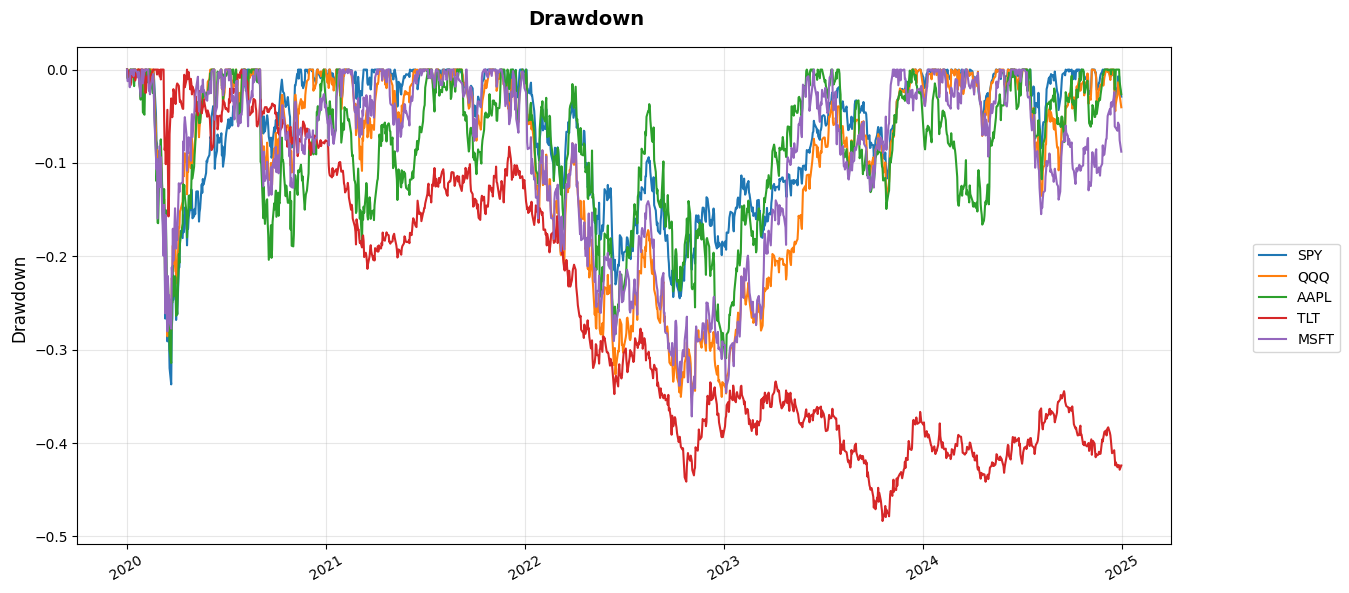

In [5]:
fig=drawdown_graph(df,tickers)
plt.tight_layout()
plt.show()

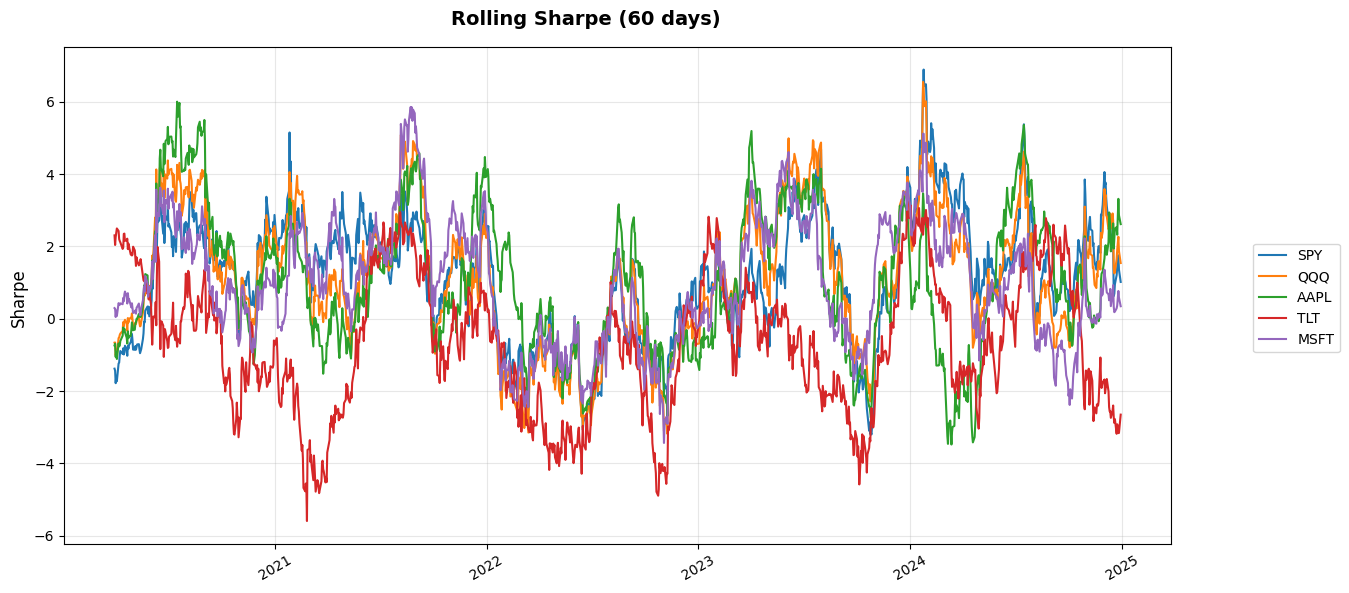

In [6]:
fig=rolling_sharpe_graph(df,tickers)
plt.tight_layout()
plt.show()